In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [4]:
np.random.seed(42)

n = 500

x = np.random.uniform(-5, 5, n)

y = np.random.uniform(0, 30, n)

labels = (y > x**2 + 3).astype(int)

data = pd.DataFrame({
    'x1': x,
    'x2': y,
    'label': labels
})

print(data.shape)

data.head()

(500, 3)


,x1,x2,label
0,-1.254599,20.944851,1
1,4.507143,16.082891,0
2,2.319939,9.285828,1
3,0.986585,24.413851,1
4,-3.439814,20.541935,1


In [5]:
print("Missing Values:")

print(data.isnull().sum())

print("\nClass Distribution:")

print(data['label'].value_counts())

Missing Values:
x1       0
x2       0
label    0
dtype: int64

Class Distribution:
label
1    299
0    201
Name: count, dtype: int64


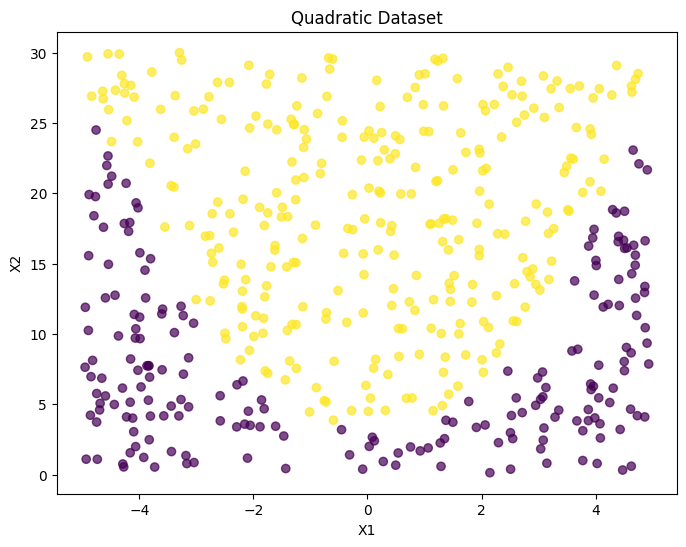

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(
    data['x1'],
    data['x2'],
    c=data['label'],
    alpha=0.7
)

plt.xlabel("X1")
plt.ylabel("X2")

plt.title(
    "Quadratic Dataset"
)

plt.show()

In [7]:
X = data[['x1', 'x2']]

y = data['label']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=5
)

print(X_train.shape)

print(y_train.shape)

print(X_test.shape)

print(y_test.shape)

(350, 2)
(350,)
(150, 2)
(150,)


In [9]:
sc = StandardScaler()

X_train_scaled = sc.fit_transform(
    X_train
)

X_test_scaled = sc.transform(
    X_test
)

In [10]:
model = SVC(
    kernel='poly',
    degree=2,
    C=10,
    coef0=1,
    gamma='scale',
    random_state=0
)

model.fit(
    X_train_scaled,
    y_train
)

print(
    "SVM model trained successfully."
)

SVM model trained successfully.


In [11]:
svm_prediction = model.predict(
    X_test_scaled
)

print(
    "SVM Prediction:"
)

print(
    svm_prediction
)

SVM Prediction:
[0 1 1 1 1 1 0 1 1 0 0 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1
 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1 0
 0 0 0 1 1 1 1 0 0 0 1 0 1 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 1 1 0 1 1 1 1 1 0
 1 0 1 0 1 1 1 1 0 0 1 0 1 1 1 0 0 1 0 0 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 1 0
 1 0]


In [12]:
conf_mat = confusion_matrix(
    y_test,
    svm_prediction
)

print(
    "SVC [Polynomial Kernel Degree 2]"
)

print(
    "\nConfusion Matrix:"
)

print(
    conf_mat
)


accuracy = accuracy_score(
    y_test,
    svm_prediction
)

print(
    "\nAccuracy Score:",
    accuracy
)

print(
    "Accuracy in Percentage:",
    round(accuracy * 100, 2),
    "%"
)


print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_test,
        svm_prediction
    )
)

SVC [Polynomial Kernel Degree 2]

Confusion Matrix:
[[64  1]
 [ 0 85]]

Accuracy Score: 0.9933333333333333
Accuracy in Percentage: 99.33 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        65
           1       0.99      1.00      0.99        85

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



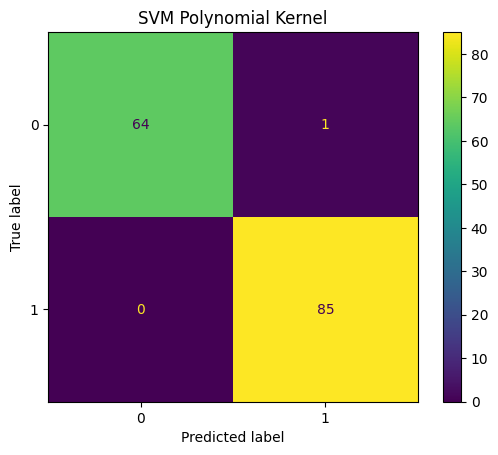

In [13]:
ConfusionMatrixDisplay(
    confusion_matrix=conf_mat
).plot()

plt.title(
    "SVM Polynomial Kernel"
)

plt.show()

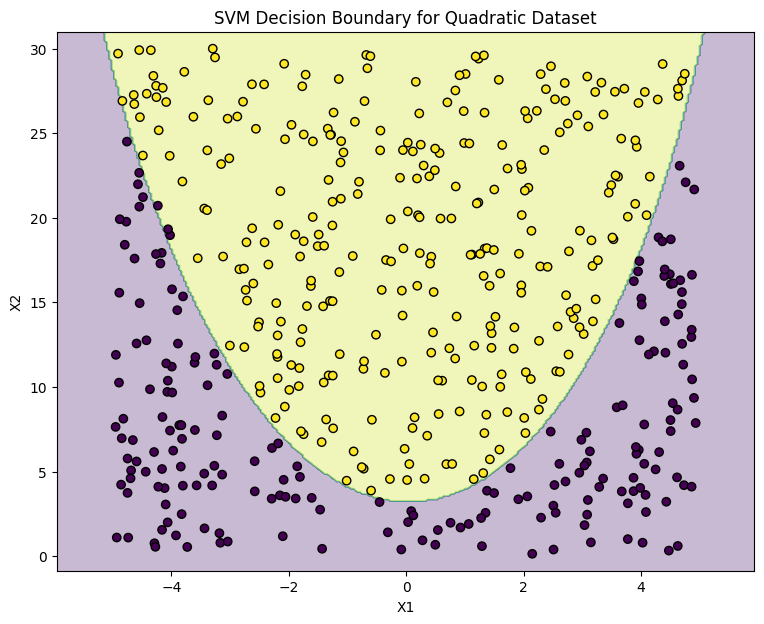

In [14]:
x1_min = X['x1'].min() - 1
x1_max = X['x1'].max() + 1

x2_min = X['x2'].min() - 1
x2_max = X['x2'].max() + 1


xx, yy = np.meshgrid(
    np.linspace(x1_min, x1_max, 300),
    np.linspace(x2_min, x2_max, 300)
)


grid = pd.DataFrame({
    'x1': xx.ravel(),
    'x2': yy.ravel()
})


grid_scaled = sc.transform(grid)

Z = model.predict(
    grid_scaled
)

Z = Z.reshape(
    xx.shape
)


plt.figure(
    figsize=(9, 7)
)

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X['x1'],
    X['x2'],
    c=y,
    edgecolors='k'
)

plt.xlabel("X1")

plt.ylabel("X2")

plt.title(
    "SVM Decision Boundary for Quadratic Dataset"
)

plt.show()

In [15]:
data.to_csv(
    "quadratic_svm_dataset.csv",
    index=False
)

print(
    "Dataset saved successfully."
)

Dataset saved successfully.
